# Laborator 2 

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter
import re
import unicodedata
from nltk.corpus import wordnet as wn
from sklearn.preprocessing import MinMaxScaler
import os

## Problema 1.a - Analiza datelor

In [6]:
df_raw = pd.read_csv('C:\\Laborator AI\\surveyDataSience.csv', low_memory=False)
df = df_raw.iloc[1:].reset_index(drop=True)

# Numar respondenti, atribute
print(f'Număr respondenți: {len(df)}')
print(f'Număr atribute: {df.shape[1]}')

# Complete data
print(f'Respondenți cu date complete: {len(df.dropna())}')

# Educatie
edu_map = {'Bachelor’s degree': 3, 'Master’s degree': 5, 'Doctoral degree': 8}
df['edu_years'] = df['Q4'].map(edu_map)

print(f"Medie ani studii (Toți): {df['edu_years'].mean():.2f}")
print(f"Medie ani studii (RO): {df[df['Q3'] == 'Romania']['edu_years'].mean():.2f}")
print(f"Medie ani studii (RO Femei): {df[(df['Q3'] == 'Romania') & (df['Q2'] == 'Woman')]['edu_years'].mean():.2f}")

# Femei cu date complete
print(f'Femei cu date complete: {len(df[df['Q2'] == 'Woman'].dropna())}')

# Femei din Romania care programeaza in Python si C++
ro_women_python = df[(df['Q3'] == 'Romania') & (df['Q2'] == 'Woman') & (df['Q7_Part_1'] == 'Python')]
ro_women_cpp = df[(df['Q3'] == 'Romania') & (df['Q2'] == 'Woman') & (df['Q7_Part_5'] == 'C++')]
print(f'Femei RO Python: {len(ro_women_python)}')
print(f'Femei RO C++: {len(ro_women_cpp)}')
print(f'Interval de vârstă Python: {ro_women_python['Q1'].value_counts().idxmax()}')
print(f'Interval de vârstă C++: {ro_women_cpp['Q1'].value_counts().idxmax()}')

# Vechime in programare
exp_map = {'< 1 years': 0.5, '1-3 years': 2, '3-5 years': 4, '5-10 years': 7.5, '10-20 years': 15, '20+ years': 25, 'I have never written code': 0}
df['exp_years'] = df['Q6'].map(exp_map)
print(df['exp_years'].describe())

Număr respondenți: 25973
Număr atribute: 369
Respondenți cu date complete: 0
Medie ani studii (Toți): 4.50
Medie ani studii (RO): 5.08
Medie ani studii (RO Femei): 5.43
Femei cu date complete: 0
Femei RO Python: 12
Femei RO C++: 4
Interval de vârstă Python: 35-39
Interval de vârstă C++: 18-21
count    25973.000000
mean         5.281061
std          6.790903
min          0.000000
25%          0.500000
50%          2.000000
75%          7.500000
max         25.000000
Name: exp_years, dtype: float64


## Problema 1.b - Vizualizarea datelor

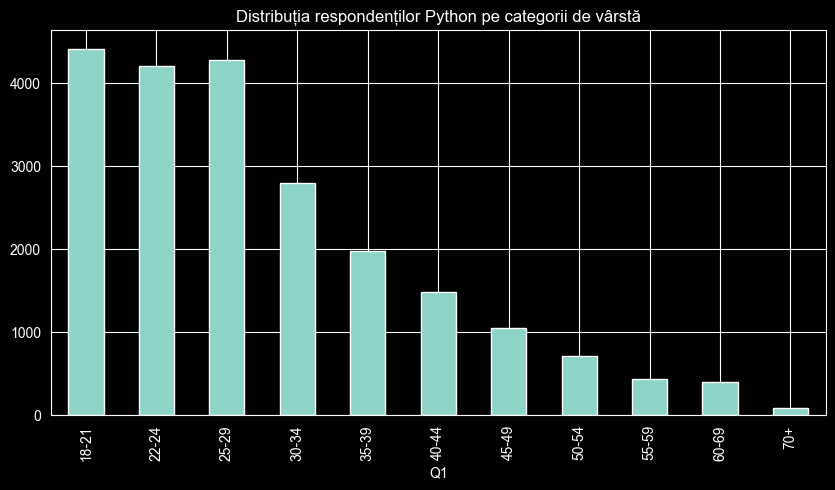

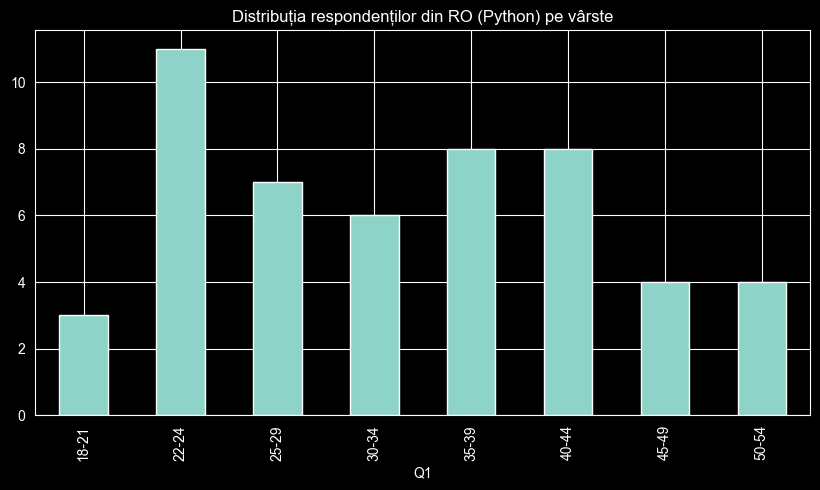

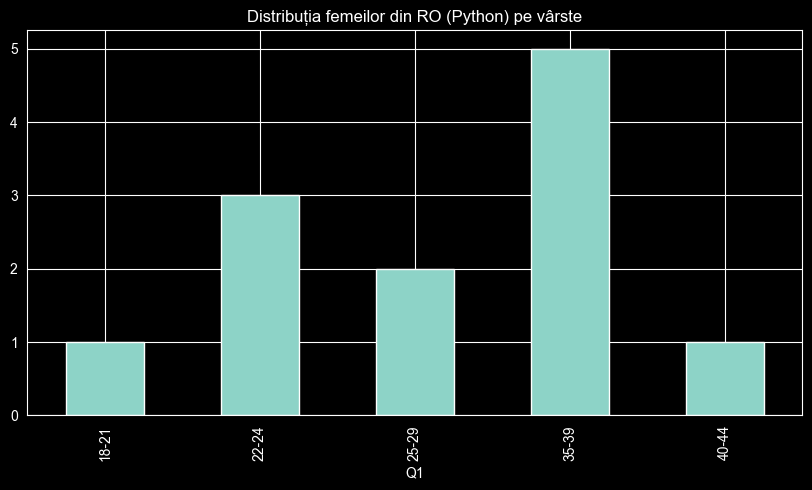

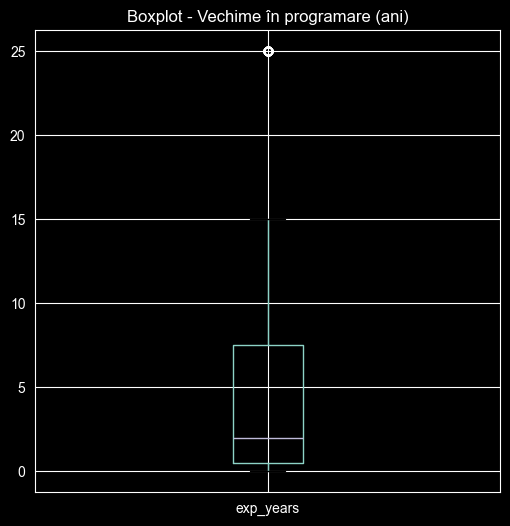

In [7]:
plt.figure(figsize=(10, 5))
df[df['Q7_Part_1'] == 'Python']['Q1'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribuția respondenților Python pe categorii de vârstă')
plt.show()

plt.figure(figsize=(10, 5))
df[(df['Q7_Part_1'] == 'Python') & (df['Q3'] == 'Romania')]['Q1'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribuția respondenților din RO (Python) pe vârste')
plt.show()

plt.figure(figsize=(10, 5))
df[(df['Q7_Part_1'] == 'Python') & (df['Q3'] == 'Romania') & (df['Q2'] == 'Woman')]['Q1'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribuția femeilor din RO (Python) pe vârste')
plt.show()

plt.figure(figsize=(6, 6))
df.boxplot(column='exp_years')
plt.title('Boxplot - Vechime în programare (ani)')
plt.show()

## Problema 2 - Prelucrarea Imaginilor

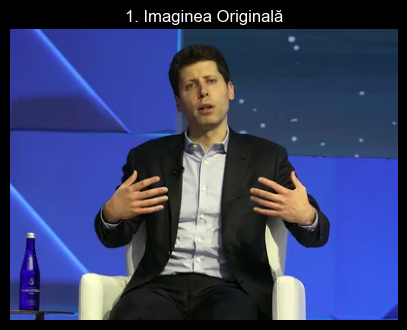

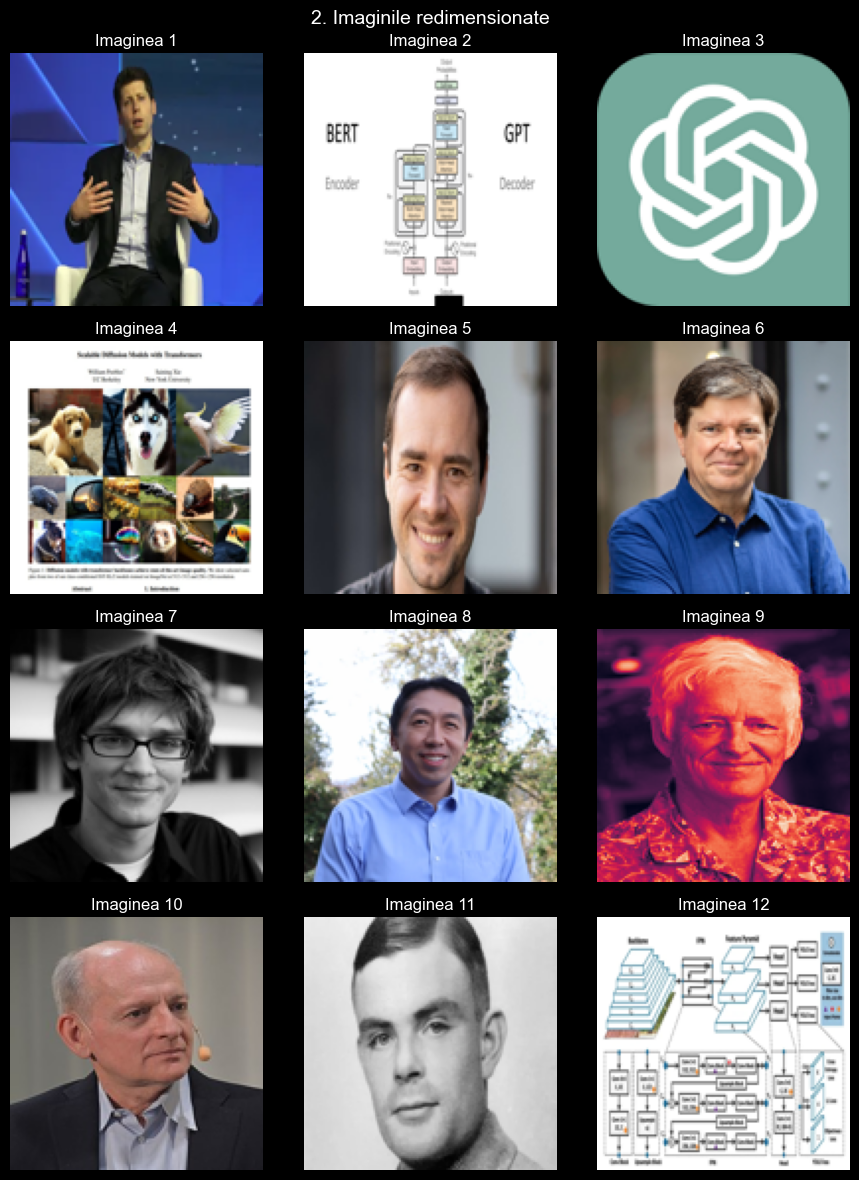

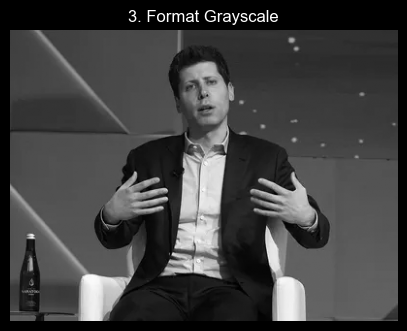

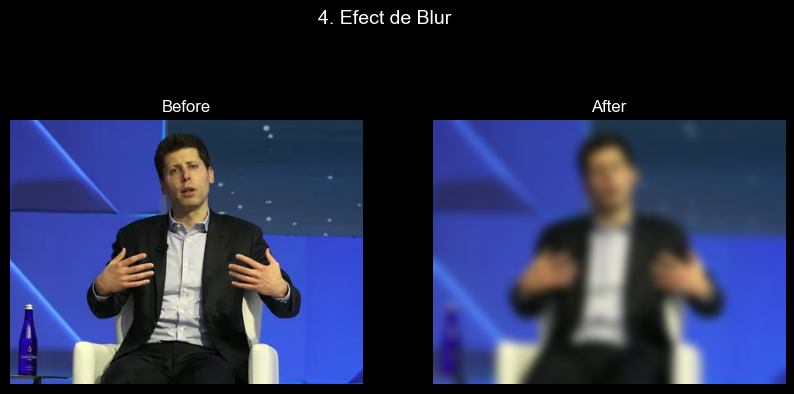

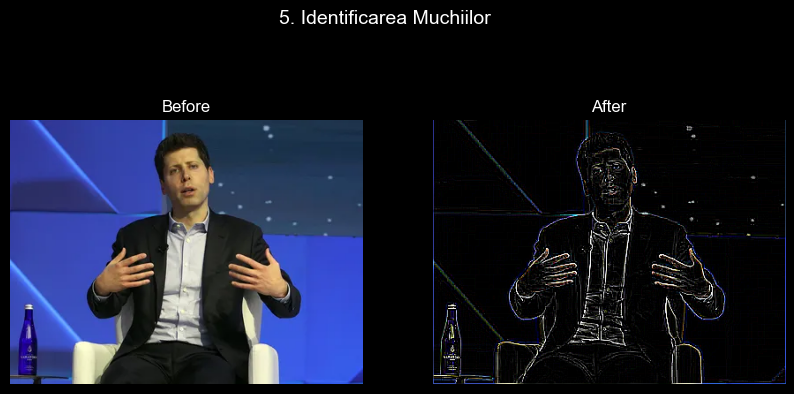

In [12]:
# Definim calea catre folder
img_folder = 'C:\\Laborator AI\\images'
image_files = []

# Cautam dinamic toate fisierele din folder care pot fi deschise ca imagini
if os.path.exists(img_folder):
    for filename in os.listdir(img_folder):
        filepath = os.path.join(img_folder, filename)
        if os.path.isfile(filepath):
            try:
                with Image.open(filepath) as img_test:
                    img_test.verify()
                image_files.append(filepath)
            except Exception:
                pass

# 1. Vizualizare una din imagini (o luam pe prima gasita)
img_path = image_files[0]
img = Image.open(img_path)

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title('1. Imaginea Originală')
plt.axis('off')
plt.show()

# 2. Redimensionare la 128x128 a tuturor imaginilor gasite si afisare in tabel
cols = 3
rows = (len(image_files) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*3))
# Asiguram un format de lista (1D array) pentru iterare usoara
axes = [axes] if len(image_files) == 1 else axes.flatten()

for i, ax in enumerate(axes):
    if i < len(image_files):
        im_resized = Image.open(image_files[i]).resize((128, 128))
        ax.imshow(im_resized)
        ax.set_title(f'Imaginea {i+1}')
    ax.axis('off')

plt.suptitle('2. Imaginile redimensionate', fontsize=14)
plt.tight_layout()
plt.show()

# 3. Transformare in format Gray-levels (folosim prima imagine)
img_gray = img.convert('L')
plt.figure(figsize=(5, 5))
plt.imshow(img_gray, cmap='gray')
plt.title('3. Format Grayscale')
plt.axis('off')
plt.show()

# 4. Blur (Before-After)
img_blur = img.filter(ImageFilter.GaussianBlur(5))
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img); ax[0].set_title('Before'); ax[0].axis('off')
ax[1].imshow(img_blur); ax[1].set_title('After'); ax[1].axis('off')
plt.suptitle('4. Efect de Blur', fontsize=14)
plt.show()

# 5. Muchii (Before-After)
img_edges = img.filter(ImageFilter.FIND_EDGES)
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img); ax[0].set_title('Before'); ax[0].axis('off')
ax[1].imshow(img_edges); ax[1].set_title('After'); ax[1].axis('off')
plt.suptitle('5. Identificarea Muchiilor', fontsize=14)
plt.show()

## Problema 3 - Prelucrare Text

In [18]:
with open('C:\\Laborator AI\\texts.txt', 'r', encoding='utf-8') as f:
    text = f.read()

def remove_diacritics(input_str):
    nfkd_form = unicodedata.normalize('NFKD', input_str)
    return u''.join([c for c in nfkd_form if not unicodedata.combining(c)])

sentences = re.split(r'[.!?]+', text)
sentences = [s.strip() for s in sentences if s.strip()]

words = re.findall(r'\b[a-zA-ZăâîșțĂÂÎȘȚ]+\b', text.lower())
unique_words = set(words)
longest_word = max(unique_words, key=len)

synonyms = set()
for synset in wn.synonyms(longest_word, lang='ron'):
    for syn in synset:
        synonyms.add(syn)

print(f'Propoziții: {len(sentences)}')
print(f'Cuvinte: {len(words)}')
print(f'Cuvinte unice: {len(unique_words)}')
print(f'Cel mai scurt: {min(unique_words, key=len)}')
print(f'Cel mai lung: {longest_word}')
if synonyms: print(f'Sinonime pentru {longest_word}: {synonyms}')
else: print(f"Nu am gasit sinonime pentru {longest_word}")

text_no_diacritics = remove_diacritics(text)
print('\nText fara diacritice:\n', text_no_diacritics)

Propoziții: 10
Cuvinte: 158
Cuvinte unice: 90
Cel mai scurt: o
Cel mai lung: confiiiiiiiiiiiiiiiiiiiiiiiiiiiirm
Nu am gasit sinonime pentru confiiiiiiiiiiiiiiiiiiiiiiiiiiiirm

Text fara diacritice:
 Mesaj de informare: 
Cursul si laboratoarele de Inteligenta Artificiala vor fi o 
provocare pentru toti. Suntem convinsi ca veti realiza proiecte 
foarte interesante. Va incurajam sa adresati intrebari atunci 
cand ceva nu e clar, atat in mod live, cat si folosind platforma 
Teams, canalul ”general”. 
Daca ati citit pana aici, va rugam sa lasati un mesaj pe canalul 
general cu textul ”Confiiiiiiiiiiiiiiiiiiiiiiiiiiiirm ca am citit 
textul pentru problema 3 din lab2”. 
--
Mesaj de informare generat de ChatGPT:
Stimati cursanti,
Suntem incantati sa va avem in echipa noastra pentru Cursul si 
laboratoarele de Inteligenta Artificiala. Aceasta experienta va 
fi o adevarata provocare, dar suntem convinsi ca veti realiza 
proiecte extrem de interesante.
Va incurajam sa fiti activi si sa adresati i

## Problema 4 - Normalizare

In [19]:
scaler = MinMaxScaler()

# Problema 1
df_norm = pd.DataFrame(scaler.fit_transform(df[['edu_years', 'exp_years']].dropna()), columns=['edu_years_norm', 'exp_years_norm'])
print('Normalizare Date (1):\n', df_norm.head())

# Problema 2
img_norm = np.array(img_gray) / 255.0
print('\nNormalizare Pixeli (2) - min/max:\n', img_norm.min(), img_norm.max())

# Pb 3
from collections import Counter
sentence_0_words = re.findall(r'\b\w+\b', sentences[0].lower())
word_counts = Counter(sentence_0_words)
total_words = len(sentence_0_words)
norm_word_freq = {word: count / total_words for word, count in word_counts.items()}
print('\nFrecvență normalizată cuvinte din prima prop (3):\n', norm_word_freq)

Normalizare Date (1):
    edu_years_norm  exp_years_norm
0             0.0            0.30
1             0.4            1.00
2             0.4            0.08
3             1.0            1.00
4             1.0            0.02

Normalizare Pixeli (2) - min/max:
 0.0 1.0

Frecvență normalizată cuvinte din prima prop (Pb 3):
 {'mesaj': 0.06666666666666667, 'de': 0.13333333333333333, 'informare': 0.06666666666666667, 'cursul': 0.06666666666666667, 'și': 0.06666666666666667, 'laboratoarele': 0.06666666666666667, 'inteligență': 0.06666666666666667, 'artificială': 0.06666666666666667, 'vor': 0.06666666666666667, 'fi': 0.06666666666666667, 'o': 0.06666666666666667, 'provocare': 0.06666666666666667, 'pentru': 0.06666666666666667, 'toți': 0.06666666666666667}
